# Mosaic and stacked bar plots

Both are now **shipped and wired into `.plot()`** -- `type="mosaic"` and
`type="stackedbar"`. (This notebook used to exercise a draft module in
`team/new_graphics/mosaic.py` before integration; it now uses the real
implementation in `symbulate/plot.py`.)

Both are for two discrete-ish or categorical variables -- the same
configuration `tile` targets -- but they encode information differently:

- **Column widths** are proportional to each `x` category's marginal
  frequency (`mosaic`), or all equal (`stackedbar`).
- **Segment heights within a column** are proportional to that column's
  *conditional* frequency of each `y` category, in both types.
- For a mosaic, every rectangle's **area** is therefore proportional to the
  joint frequency of that `(x, y)` pair.

The helpers `make_mosaic` / `make_stackedbar` take raw arrays; `.plot()` is
the normal way in.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from symbulate import *
from symbulate.plot import make_mosaic, make_stackedbar

rng = np.random.default_rng(0)

## 1. Two discrete numeric variables, unequal category sizes

`x` takes values 1-4 with unequal probabilities (0.5, 0.3, 0.15, 0.05); `y` is
`Poisson(2)`. The column widths should clearly differ, tracking `x`'s marginal
probabilities -- the easiest way to confirm the width geometry.

`Poisson(2)` also produces more than 7 distinct values in a 4000-point
simulation, more than the 7 hues in the Okabe-Ito palette -- so this doubles as
the test case for color reuse: categories past the 7th repeat an earlier color
*plus* a hatch pattern, and a `UserWarning` explains why.

C:\Users\agw07\AppData\Local\Temp\ipykernel_18212\1849265581.py:5: UserWarning: This plot has 9 distinct y-values, more than the 7 colors in the categorical palette, so some categories repeat a color (distinguished with a hatch pattern instead). Stacked segments are hard to read with this many categories -- consider a plot type that doesn't rely on category color, like a tile plot.
  make_mosaic(x, y, ax, xlabel="X", ylabel="Y")


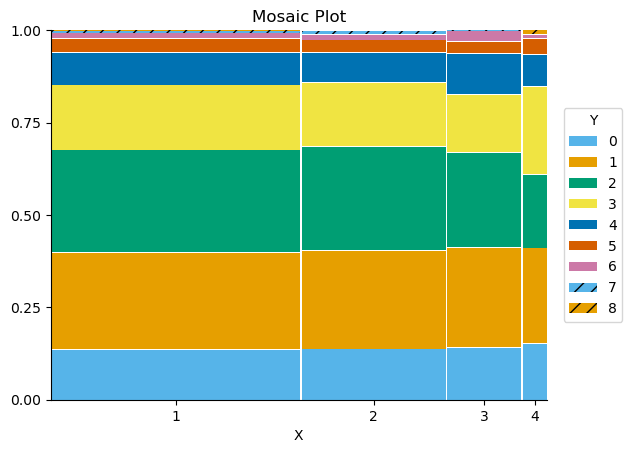

In [2]:
x = rng.choice([1, 2, 3, 4], size=4000, p=[0.5, 0.3, 0.15, 0.05])
y = rng.poisson(2, 4000)

ax = plt.gca()
make_mosaic(x, y, ax, xlabel="X", ylabel="Y")
plt.show()  # column 1 widest (p=0.5), column 4 narrowest (p=0.05)

## 2. Independence vs. association -- the core diagnostic use

The whole point: if `x` and `y` are independent, every column's segments have
(roughly) the same relative heights, since `y`'s conditional distribution
doesn't depend on `x`. If they're associated, the heights visibly change from
column to column.

### 2a. Independent -- `Outcome` doesn't depend on `Group`

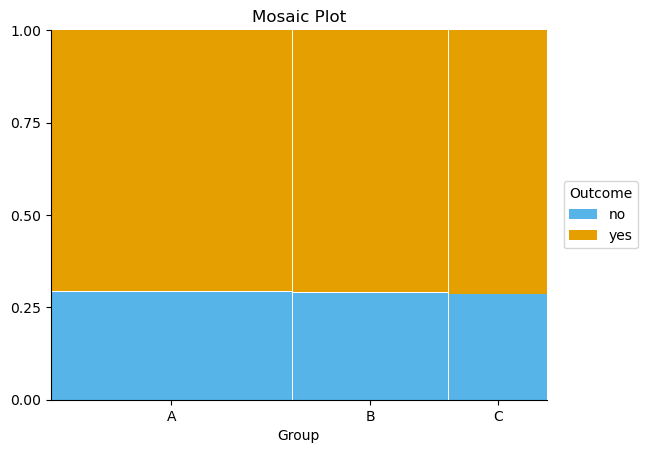

In [3]:
group_indep = rng.choice(["A", "B", "C"], size=4000, p=[0.5, 0.3, 0.2])
outcome_indep = rng.choice(["yes", "no"], size=4000, p=[0.7, 0.3])

ax = plt.gca()
make_mosaic(group_indep, outcome_indep, ax, xlabel="Group", ylabel="Outcome")
plt.show()  # every column: ~70% yes / ~30% no

### 2b. Associated -- `Outcome` depends heavily on `Group`

`P(yes)` is 0.85 for Group A, 0.5 for Group B, and 0.15 for Group C. The
segment heights should visibly flip from mostly-yes on the left to mostly-no
on the right.

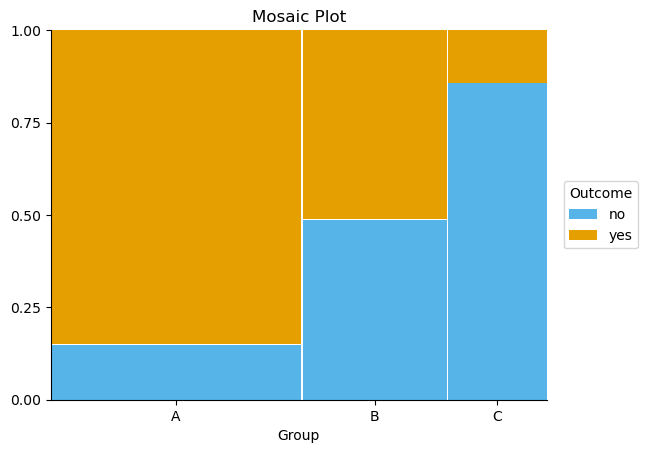

In [4]:
group = rng.choice(["A", "B", "C"], size=4000, p=[0.5, 0.3, 0.2])
p_yes = np.select([group == "A", group == "B", group == "C"], [0.85, 0.5, 0.15])
outcome = np.where(rng.uniform(size=4000) < p_yes, "yes", "no")

ax = plt.gca()
make_mosaic(group, outcome, ax, xlabel="Group", ylabel="Outcome")
plt.show()  # Group A mostly yes, Group C mostly no

## 3. Mosaic vs. stacked bar

Same data, side by side. Only the column widths change -- every segment height
is identical between the two panels.

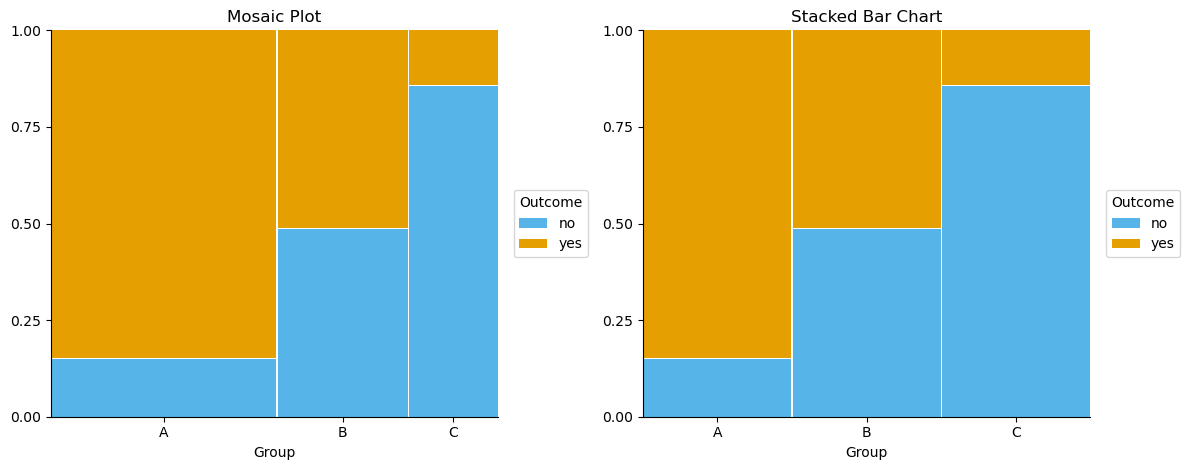

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

make_mosaic(group, outcome, axes[0], xlabel="Group", ylabel="Outcome")
make_stackedbar(group, outcome, axes[1], xlabel="Group", ylabel="Outcome")

plt.tight_layout()
plt.show()

## 4. No in-cell labels

Each cell used to print its conditional proportion. Those were removed: a
number in every cell crowded out the shapes the plot exists to show, and the
segment heights already encode the same quantity against the 0-to-1 scale on
the left. (`normalize=` is not accepted by either helper for the same reason
-- the geometry is always proportions.)

free-floating text artists on the axes: 0


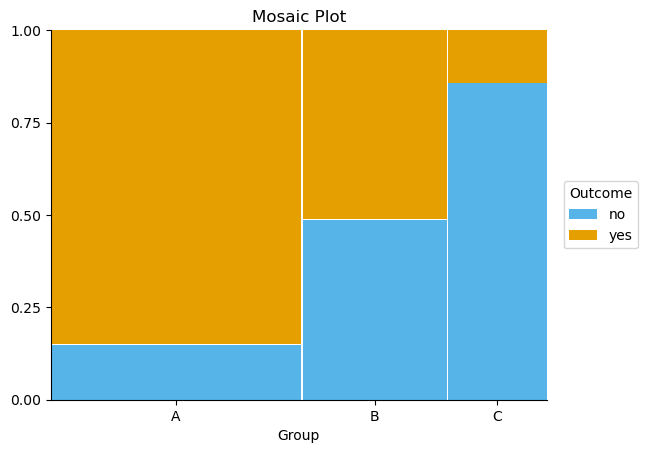

In [6]:
ax = plt.gca()
make_mosaic(group, outcome, ax, xlabel="Group", ylabel="Outcome")
print("free-floating text artists on the axes:", len(ax.texts))
plt.show()

## 5. Every column spans 0 to 1

A column missing one of the `y` categories used to stop slightly short of 0 or
1, because the absent category's gap was still reserved. Now gaps are only
reserved *between* segments that actually have positive height.

Here `y` is never `"low"` in group `"C"`:

every visible segment top <= 1, tallest reaches: 1.0


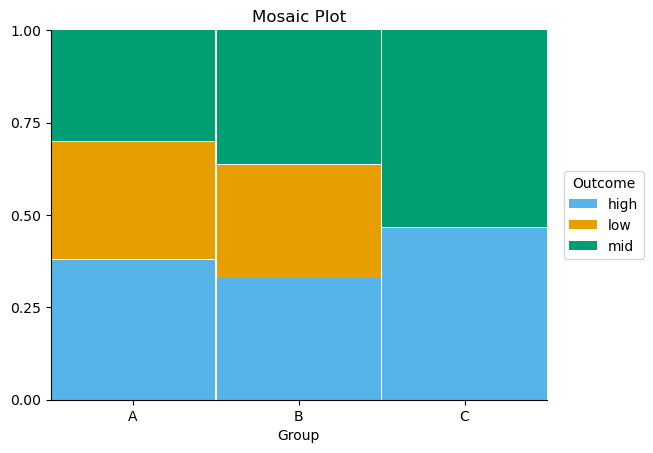

In [7]:
g = np.repeat(["A", "B", "C"], 400)
o = np.where(
    g == "C",
    rng.choice(["mid", "high"], size=1200),
    rng.choice(["low", "mid", "high"], size=1200),
)

ax = plt.gca()
make_mosaic(g, o, ax, xlabel="Group", ylabel="Outcome")
tops = [round(b.get_y() + b.get_height(), 6) for b in ax.patches if b.get_height() > 0]
print("every visible segment top <= 1, tallest reaches:", max(tops))
plt.show()

## 6. Overlay is refused

Each of these fills the whole axes, so a second one drawn over the first is
never readable. This is the hard-error tier of the overlay policy, not the
readability-warning tier `tile` and `hist2d` use -- and it is checked *before*
anything is drawn, so the first plot is left intact.

ValueError: Overlaying a mosaic or stacked bar plot with another plot won't work -- each one fills the whole plot area, so they would cover each other up. Please run them separately (one .plot() per cell), or try a different plot type.
first plot untouched: True


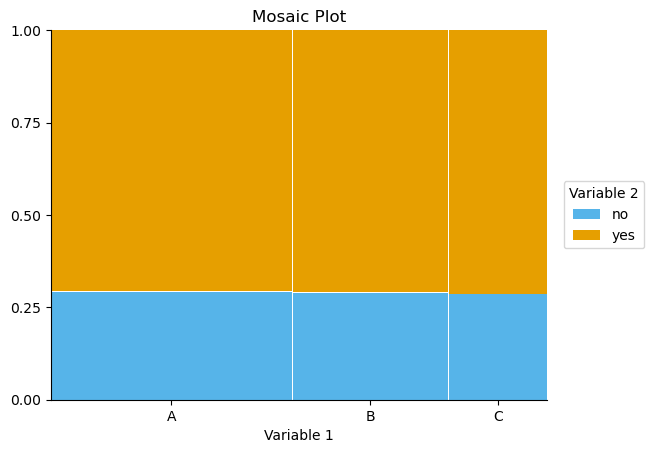

In [8]:
ax = plt.gca()
make_mosaic(group_indep, outcome_indep, ax)
n_before = len(ax.patches)
try:
    make_mosaic(group, outcome, ax)
except ValueError as e:
    print("ValueError:", e)
print("first plot untouched:", len(ax.patches) == n_before)
plt.show()

## 7. A crowded mosaic gets a note, not a different plot

Past 4 categories on either axis a mosaic's rarer columns get too thin to
compare, so Symbulate says so -- but still draws the mosaic you asked for.
Nothing is ever substituted, in either direction. `resolve_mosaic_type`
returns just the message (or `None`).

In [9]:
from symbulate.plot import resolve_mosaic_type

small_x, small_y = ["a", "b"] * 20, ["p", "q"] * 20
big_x, big_y = [f"x{i}" for i in range(6)] * 10, ["p", "q"] * 30

for label, xs, ys, t in [
    ("mosaic,     2 categories", small_x, small_y, "mosaic"),
    ("mosaic,     6 categories", big_x, big_y, "mosaic"),
    ("stackedbar, 2 categories", small_x, small_y, "stackedbar"),
    ("stackedbar, 6 categories", big_x, big_y, "stackedbar"),
]:
    print(f"{label} -> {resolve_mosaic_type(xs, ys, t)}")

mosaic,     2 categories -> None
mosaic,     6 categories -> Mosaic plots get messy when there are many possible pairs (6x2 here); try type="stackedbar" or type="tile" instead.
stackedbar, 2 categories -> None
stackedbar, 6 categories -> None


## 8. Two categorical variables default to a mosaic

Two dependent categorical variables built from a raw `ProbabilitySpace` used to
fall through to the path-plot catch-all and draw each pair as a meaningless
two-point line titled "Sample Path". They now route to a mosaic, which answers
the question they are almost always simulated to ask: does `b`'s distribution
change with `a`?

Currently Showing: Mosaic Plot (Default)
Alternative Plots: Stacked Bar Chart (type = "stackedbar"), Tile Plot (type = "tile")


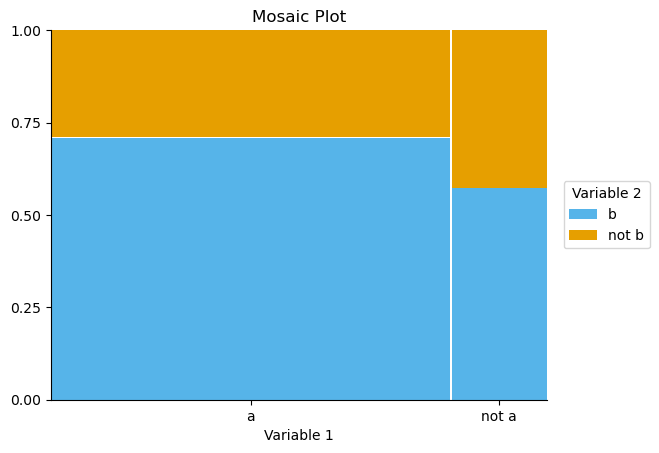

In [10]:
def event_sim():
    a = BoxModel(["a", "not a"], probs=[0.8, 0.2]).draw()
    if a == "a":
        b = BoxModel(["b", "not b"], probs=[0.7, 0.3]).draw()
    else:
        b = BoxModel(["b", "not b"], probs=[0.6, 0.4]).draw()
    return a, b


X, Y = RV(ProbabilitySpace(event_sim))
(X & Y).sim(2000).plot()

The `"a"` column is about four times wider (0.8 vs 0.2), and the `"b"` segment
is visibly taller in it (0.7 vs 0.6) -- both the marginal and the dependence,
read straight off the picture.

`type="stackedbar"` and `type="tile"` are the alternatives; a categorical
scatter is not offered, since `make_scatter`'s jitter modes assume numeric
positions.

## Verification checklist

- [ ] Section 1: column widths visibly track `x`'s marginal probabilities (widest to narrowest: 1, 2, 3, 4)
- [ ] Section 1: categories past the 7th repeat a color *plus* a hatch pattern, and a `UserWarning` explains why
- [ ] Section 2a (independent): segment heights look the same (~70/30) in every column
- [ ] Section 2b (associated): heights clearly differ across columns (mostly-yes left, mostly-no right)
- [ ] Section 3: the two panels differ only in column width; every segment height matches
- [ ] Section 4: no numbers printed inside the cells (`len(ax.texts)` is 0)
- [ ] Section 5: the group with a missing category still fills its column from 0 to 1
- [ ] Section 6: the second plot raises, and the first is left with its bars intact
- [ ] Section 7: a crowded mosaic prints a note and is still drawn; a stacked bar never gets one
- [ ] Section 8: the categorical pair draws a "Mosaic Plot", **not** a "Sample Path"
- [ ] Every plot: x-axis labeled with the `x` categories; 0-to-1 scale on the left; legend outside the axes, titled with `ylabel`